In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# colores
rojo = '\033[91m'
verde = '\033[92m'
azul = '\033[94m'
magenta = '\033[95m'
amarillo = '\033[93m'
rosa = '\033[38;5;200m'
turquesa = '\033[38;5;44m'
azul_marino = '\33[38;5;67m'
lima = '\33[38;5;46m'
reset = '\033[0m'

# Scikit-learn para transformaciones
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Configuración de visualización
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Verificar versiones
print(f"{lima}Pandas versión:{reset} {pd.__version__}")
print(f"{lima}NumPy versión:{reset} {np.__version__}")
import sklearn
print(f"{lima}Scikit-learn versión:{reset} {sklearn.__version__}")

Pandas versión: 2.3.3
NumPy versión: 2.2.6
Scikit-learn versión: 1.8.0


## 🟢 Ejercicio 1: Estandarización con StandardScaler

Aplica StandardScaler a un dataset de empleados:

```python
rng = np.random.default_rng(42)
df_empleados = pd.DataFrame({
    'edad': rng.integers(22, 65, 100),
    'salario': rng.integers(20000, 80000, 100),
    'años_experiencia': rng.integers(0, 40, 100)
})
```

**Tareas:**
1. Muestra las estadísticas originales (media y desviación estándar) de cada columna
2. Aplica `StandardScaler` a todas las columnas numéricas
3. Muestra las estadísticas después del escalado (deben ser media≈0, std≈1)
4. Crea un gráfico comparando la distribución antes y después del escalado
5. Explica con tus palabras: ¿qué hace StandardScaler?

Estadísticas Originales
           edad       salario  años_experiencia
mean  44.130000  49464.330000         18.670000
std   11.729833  16620.767745         10.733743

Estadísticas después de StandardScaler
      edad  salario  años_experiencia
mean -0.00    -0.00             -0.00
std   1.01     1.01              1.01

Gráficos comparativos


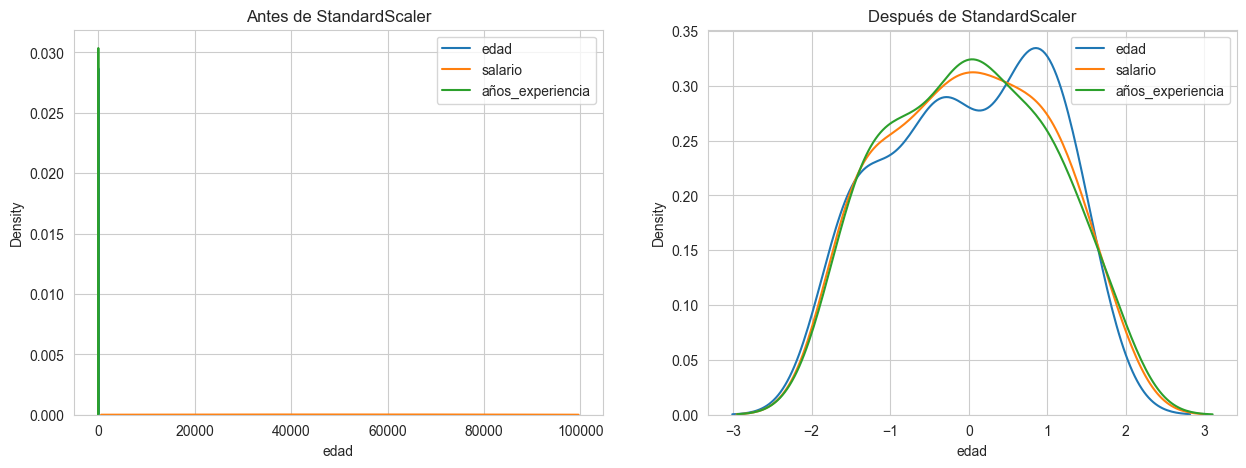


StandardScaler lo que hace es poner todas las variables en la misma escala.
Esto sirve para que los modelos de machine learning funcionen mejor y no le den más
importancia a variables con números más grandes.
Por eso no se ven las líneas en el gráfico de 'Antes de StandardScaler', pues las curvas
de edad y años de experiencia quedan aplastadas en 0


In [5]:
# Crear el DataFrame
rng = np.random.default_rng(42)
df_empleados = pd.DataFrame({
    'edad': rng.integers(22, 65, 100),
    'salario': rng.integers(20000, 80000, 100),
    'años_experiencia': rng.integers(0, 40, 100)
})

# Estadísticas originales
print(f"{azul}Estadísticas Originales{reset}")
print(df_empleados.agg(['mean', 'std']))

# Aplicar StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_empleados), columns=df_empleados.columns)

# Estadísticas después del escalado
print(f"\n{azul}Estadísticas después de StandardScaler{reset}")
print(df_scaled.agg(['mean', 'std']).round(2)) # Debería ser mean 0 y std 1

# Gráfico comparativo
print(f"\n{azul}Gráficos comparativos{reset}")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Antes de escalar
for col in df_empleados.columns:
    sns.kdeplot(df_empleados[col], ax=ax1, label=col)
ax1.set_title("Antes de StandardScaler")
ax1.legend()

# Después de escalar
for col in df_scaled.columns:
    sns.kdeplot(df_scaled[col], ax=ax2, label=col)
ax2.set_title("Después de StandardScaler")
ax2.legend()
plt.show()

print(f"\n{lima}StandardScaler lo que hace es poner todas las variables en la misma escala.{reset}")
print(f"{lima}Esto sirve para que los modelos de machine learning funcionen mejor y no le den más{reset}")
print(f"{lima}importancia a variables con números más grandes.{reset}")
print(f"{lima}Por eso no se ven las líneas en el gráfico de 'Antes de StandardScaler', pues las curvas{reset}")
print(f"{lima}de edad y años de experiencia quedan aplastadas en 0{reset}")

## 🟢 Ejercicio 2: Normalización con MinMaxScaler

Usando el mismo dataset de empleados:

**Tareas:**
1. Aplica `MinMaxScaler` para escalar los datos al rango [0, 1]
2. Verifica que todos los valores están entre 0 y 1
3. Aplica MinMaxScaler con rango personalizado [0, 10]
4. Compara visualmente StandardScaler vs MinMaxScaler en un gráfico
5. Explica: ¿Cuándo es mejor usar MinMaxScaler en lugar de StandardScaler?


Rango [0,1]: Min: 0.0, Max: 1.0


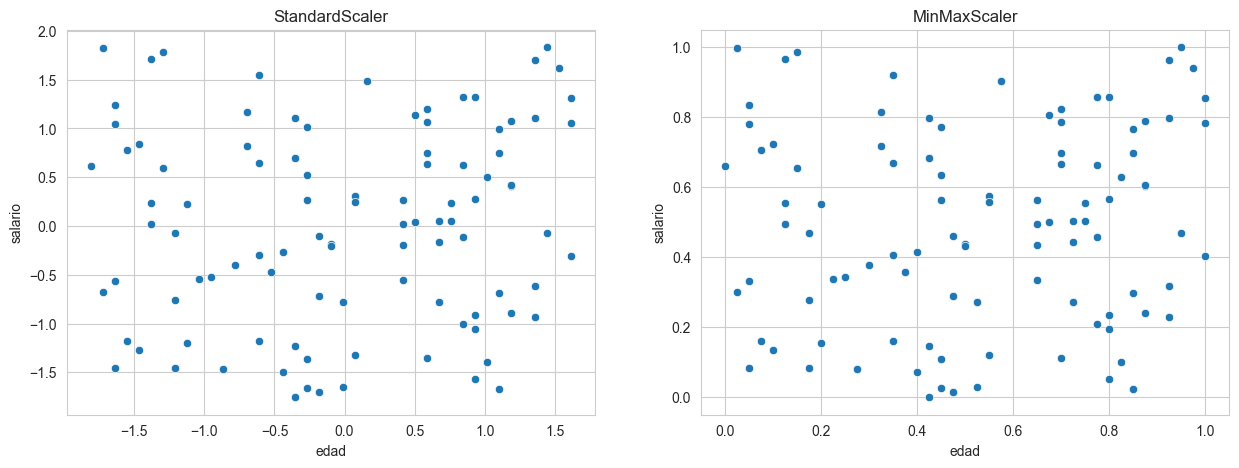

Es mejor usar MinMaxScaler cuando los datos no tienen valores extremos y quiero que todo 
quede ordenado entre 0 y 1. 


In [ ]:
# Aplicar MinMaxScaler [0, 1]
min_max = MinMaxScaler()
df_minmax = pd.DataFrame(min_max.fit_transform(df_empleados), columns=df_empleados.columns)
print(f"{azul}\nRango [0,1]: {reset}Min: {df_minmax.min().min()}, Max: {df_minmax.max().max()}")

# Rango personalizado [0, 10]
min_max_10 = MinMaxScaler(feature_range=(0, 10))
df_minmax_10 = pd.DataFrame(min_max_10.fit_transform(df_empleados), columns=df_empleados.columns)

# Comparación Visual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df_scaled, x='edad', y='salario', ax=ax1).set_title("StandardScaler")
sns.scatterplot(data=df_minmax, x='edad', y='salario', ax=ax2).set_title("MinMaxScaler")
plt.show()
print(f"{lima}Es mejor usar MinMaxScaler cuando los datos no tienen valores extremos y quiero que todo{reset} ")
print(f"{lima}quede ordenado entre 0 y 1. ")

## 🟢 Ejercicio 3: RobustScaler - Escalado Robusto a Outliers

Trabaja con datos que contienen outliers:

```python
rng = np.random.default_rng(42)
# Datos normales + outliers extremos
salarios_normales = rng.normal(35000, 8000, 95)
salarios_outliers = np.array([150000, 200000, 300000, 500000, 1000000])  # CEOs
salarios = np.concatenate([salarios_normales, salarios_outliers])

df_outliers = pd.DataFrame({'salario': salarios})
```

**Tareas:**
1. Aplica StandardScaler y observa cómo se ven los datos escalados
2. Aplica MinMaxScaler y observa cómo se ven los datos escalados
3. Aplica RobustScaler y observa cómo se ven los datos escalados
4. Crea un gráfico comparativo de los tres métodos (3 histogramas)
5. Explica: ¿Por qué RobustScaler maneja mejor los outliers?

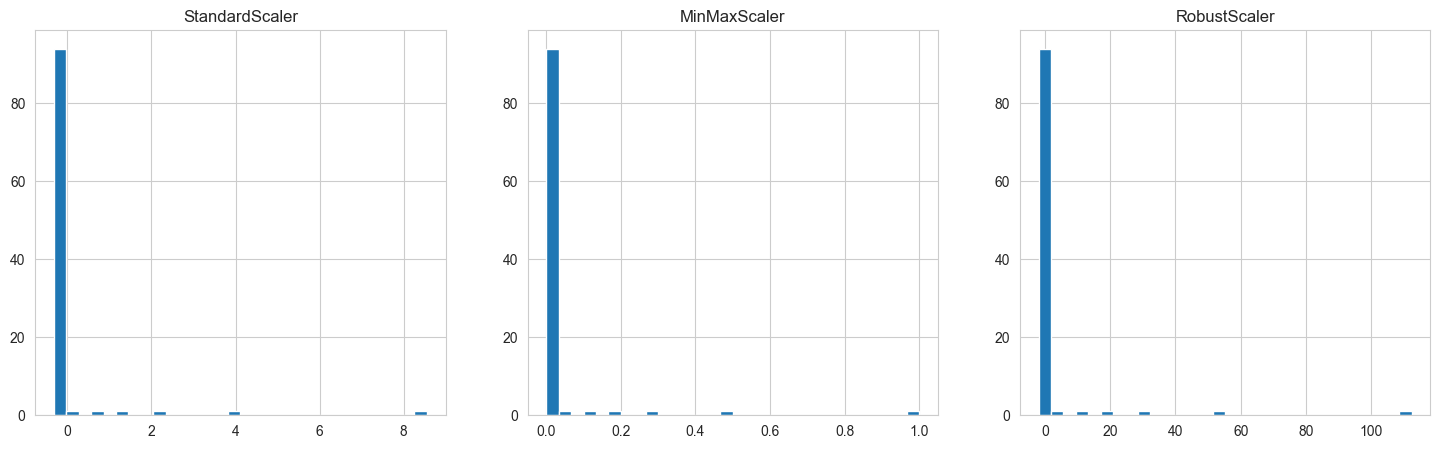

El RobustScaler es mejor con los valores extremos porque ignora los datos 'locos' y se
fija sólo en los que están en el centro (mediana) para hacer sus cáculos. De esta forma, 
los valores muy altos o muy bajos no estropean la escala del resto de la información


In [ ]:
# Crear el DataFrame
rng = np.random.default_rng(42)
salarios_normales = rng.normal(35000, 8000, 95)
salarios_outliers = np.array([150000, 200000, 300000, 500000, 1000000])
salarios = np.concatenate([salarios_normales, salarios_outliers])

df_outliers = pd.DataFrame({'salario': salarios})

# Aplicar los tres escaladores
ss = StandardScaler().fit_transform(df_outliers)
mm = MinMaxScaler().fit_transform(df_outliers)
rs = RobustScaler().fit_transform(df_outliers)

# Gráfico comparativo

print()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(ss, bins=30); axes[0].set_title("StandardScaler")
axes[1].hist(mm, bins=30); axes[1].set_title("MinMaxScaler")
axes[2].hist(rs, bins=30); axes[2].set_title("RobustScaler")
plt.show()

print(f"{lima}El RobustScaler es mejor con los valores extremos porque ignora los datos 'locos' y se{reset}")
print(f"{lima}fija sólo en los que están en el centro (mediana) para hacer sus cáculos. De esta forma,{reset} ")
print(f"{lima}los valores muy altos o muy bajos no estropean la escala del resto de la información{reset}")

## 🟡 Ejercicio 4: Codificación de Variables Categóricas - One-Hot Encoding

Codifica variables categóricas nominales (sin orden):

```python
df_categorico = pd.DataFrame({
    'ciudad': ['Madrid', 'Barcelona', 'Valencia', 'Madrid', 'Sevilla', 
               'Barcelona', 'Madrid', 'Valencia', 'Sevilla', 'Madrid'],
    'tipo_contrato': ['Indefinido', 'Temporal', 'Indefinido', 'Prácticas',
                      'Temporal', 'Indefinido', 'Prácticas', 'Temporal',
                      'Indefinido', 'Temporal'],
    'salario': [35000, 28000, 32000, 18000, 30000, 42000, 20000, 27000, 38000, 29000]
})
```

**Tareas:**
1. Usa `pd.get_dummies()` para aplicar One-Hot Encoding a 'ciudad'
2. Usa `OneHotEncoder` de sklearn para codificar 'tipo_contrato'
3. Muestra el DataFrame resultante con todas las columnas codificadas
4. Explica qué es el problema de la "trampa de las variables dummy" y cómo evitarlo
5. Usa `drop_first=True` en get_dummies y explica por qué se hace

In [ ]:
# Crear el DataFrame
df_categorico = pd.DataFrame({
    'ciudad': ['Madrid', 'Barcelona', 'Valencia', 'Madrid', 'Sevilla', 
               'Barcelona', 'Madrid', 'Valencia', 'Sevilla', 'Madrid'],
    'tipo_contrato': ['Indefinido', 'Temporal', 'Indefinido', 'Prácticas',
                      'Temporal', 'Indefinido', 'Prácticas', 'Temporal',
                      'Indefinido', 'Temporal'],
    'salario': [35000, 28000, 32000, 18000, 30000, 42000, 20000, 27000, 38000, 29000]
})

# get_dummies para 'ciudad'
df_dummies = pd.get_dummies(df_categorico, columns=['ciudad'], drop_first=True)

# OneHotEncoder para 'tipo_contrato'
ohe = OneHotEncoder(sparse_output=False)
contrato_encoded = ohe.fit_transform(df_categorico[['tipo_contrato']])
contrato_df = pd.DataFrame(contrato_encoded, columns=ohe.get_feature_names_out(['tipo_contrato']))

# Resultado final
df_final_cat = pd.concat([df_dummies.drop(columns='tipo_contrato'), contrato_df], axis=1)
print()
print(df_final_cat.head())
print(f"\n{lima}1- La 'Trampa de las variables dummy' pasa cuando hay columnas repetidas que no aportan{reset}")
print(f"{lima}   información nueva y confunden al modelo. Se evita eliminando una de las columnas creada{reset}")
print(f"\n{lima}2- Al usar 'drop_first=True', eliminamos automáticamente la primera columna de cada {reset}")
print(f"{lima}   variable, evitando los datos repetidos y así, mejorar el funcionamiento del modelo.{reset}")


   salario  ciudad_Madrid  ciudad_Sevilla  ciudad_Valencia  \
0    35000           True           False            False   
1    28000          False           False            False   
2    32000          False           False             True   
3    18000           True           False            False   
4    30000          False            True            False   

   tipo_contrato_Indefinido  tipo_contrato_Prácticas  tipo_contrato_Temporal  
0                       1.0                      0.0                     0.0  
1                       0.0                      0.0                     1.0  
2                       1.0                      0.0                     0.0  
3                       0.0                      1.0                     0.0  
4                       0.0                      0.0                     1.0  

1- La 'Trampa de las variables dummy' pasa cuando hay columnas repetidas que no aportan
   información nueva y confunden al modelo. Se evita eliminando

## 🟡 Ejercicio 5: Ordinal Encoding - Variables con Orden

Codifica variables categóricas ordinales (con orden natural):

```python
df_ordinal = pd.DataFrame({
    'nivel_estudios': ['Secundaria', 'Universidad', 'Máster', 'Secundaria', 
                       'Doctorado', 'Universidad', 'Máster', 'Secundaria',
                       'Doctorado', 'Universidad'],
    'satisfaccion': ['Baja', 'Media', 'Alta', 'Media', 'Muy Alta',
                     'Alta', 'Baja', 'Media', 'Alta', 'Muy Alta'],
    'salario': [25000, 35000, 45000, 28000, 55000, 38000, 42000, 26000, 52000, 40000]
})
```

**Tareas:**
1. Define el orden correcto para 'nivel_estudios': Secundaria < Universidad < Máster < Doctorado
2. Define el orden para 'satisfaccion': Baja < Media < Alta < Muy Alta
3. Aplica `OrdinalEncoder` especificando el orden correcto
4. Verifica que la codificación respeta el orden (Secundaria=0, Doctorado=3)
5. Explica: ¿Por qué NO debemos usar One-Hot Encoding para variables ordinales?

In [ ]:
# Crear el DataFrame
df_ordinal = pd.DataFrame({
    'nivel_estudios': ['Secundaria', 'Universidad', 'Máster', 'Secundaria', 
                       'Doctorado', 'Universidad', 'Máster', 'Secundaria',
                       'Doctorado', 'Universidad'],
    'satisfaccion': ['Baja', 'Media', 'Alta', 'Media', 'Muy Alta',
                     'Alta', 'Baja', 'Media', 'Alta', 'Muy Alta'],
    'salario': [25000, 35000, 45000, 28000, 55000, 38000, 42000, 26000, 52000, 40000]
})

# Definir órdenes
orden_estudios = ['Secundaria', 'Universidad', 'Máster', 'Doctorado']
orden_satisfaccion = ['Baja', 'Media', 'Alta', 'Muy Alta']

# Aplicar OrdinalEncoder
oe = OrdinalEncoder(categories=[orden_estudios, orden_satisfaccion])
df_ordinal[['nivel_estudios', 'satisfaccion']] = oe.fit_transform(df_ordinal[['nivel_estudios', 'satisfaccion']])

print()
print(df_ordinal.head())
print(f"{lima}\nOne-Hot Encoding no sirve para variables ordinales porque trata todas las categorías {reset}")
print(f"{lima}como si fueran iguales. No respeta el orden que pueda haber entre ellas (rangos, jerarquías...){reset}")


   nivel_estudios  satisfaccion  salario
0             0.0           0.0    25000
1             1.0           1.0    35000
2             2.0           2.0    45000
3             0.0           1.0    28000
4             3.0           3.0    55000

One-Hot Encoding no sirve para variables ordinales porque trata todas las categorías 
como si fueran iguales. No respeta el orden que pueda haber entre ellas (rangos, jerarquías...)


## 🟡 Ejercicio 6: Transformación de Distribuciones Sesgadas

Transforma una distribución sesgada para que sea más normal:

```python
rng = np.random.default_rng(42)
# Distribución exponencial (muy sesgada a la derecha)
ingresos = np.random.exponential(scale=3000, size=500) + 1000
df_sesgado = pd.DataFrame({'ingresos': ingresos})
```

**Tareas:**
1. Calcula el sesgo (skewness) de los datos originales con `scipy.stats.skew()`
2. Aplica transformación **logarítmica** (`np.log1p`)
3. Aplica transformación **Yeo-Johnson** con `PowerTransformer`
4. Compara el sesgo antes y después de cada transformación
5. Crea gráficos (histogramas) comparando: Original vs Log vs Yeo-Johnson
6. Explica: ¿Cuándo es necesario transformar la distribución de una variable?


Sesgo original: 2.12


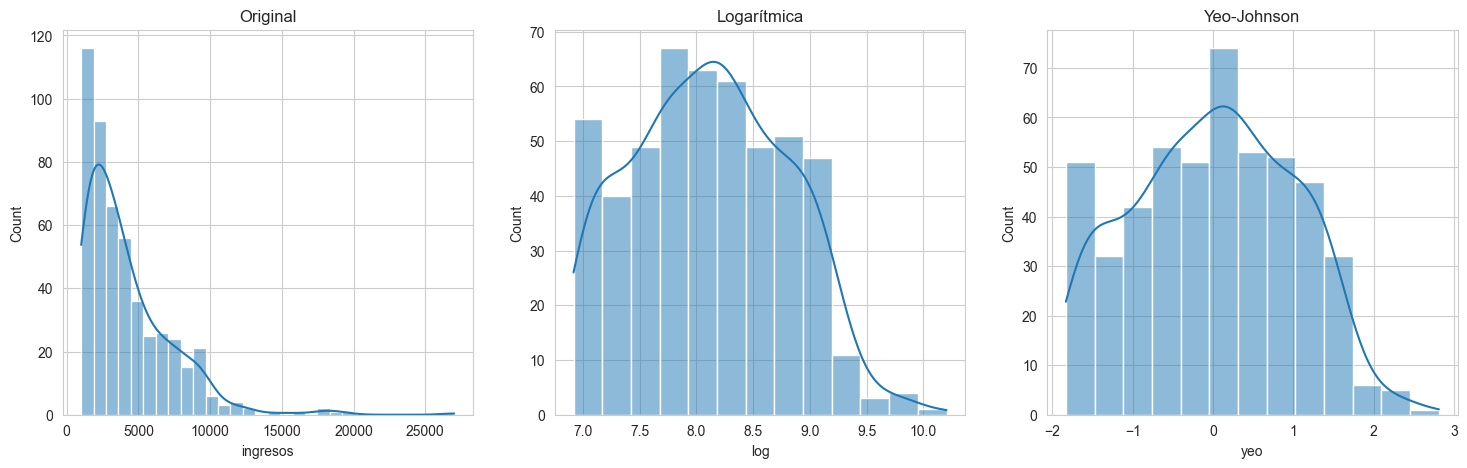

Transformamos una variable cuando los datos están muy amontonados en un lado 
dejando una'cola' larga en el otro, porque muchos algoritmos de aprendizaje automático 
funcionan mejor si los datos siguen algo parecido a una campana de Gauss


In [ ]:
# Crear el DataFrame
rng = np.random.default_rng(42)
ingresos = np.random.exponential(scale=3000, size=500) + 1000
df_sesgado = pd.DataFrame({'ingresos': ingresos})

from scipy import stats

from scipy.stats import skew

# Sesgo original
print(f"\n{azul}Sesgo original:{reset} {skew(df_sesgado['ingresos']):.2f}")

# Logarítmica
df_sesgado['log'] = np.log1p(df_sesgado['ingresos'])

# Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson')
df_sesgado['yeo'] = pt.fit_transform(df_sesgado[['ingresos']])

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_sesgado['ingresos'], kde=True, ax=axes[0]).set_title("Original")
sns.histplot(df_sesgado['log'], kde=True, ax=axes[1]).set_title("Logarítmica")
sns.histplot(df_sesgado['yeo'], kde=True, ax=axes[2]).set_title("Yeo-Johnson")
plt.show()

print(f"{lima}Transformamos una variable cuando los datos están muy amontonados en un lado {reset}")
print(f"{lima}dejando una'cola' larga en el otro, porque muchos algoritmos de aprendizaje automático {reset}")
print(f"{lima}funcionan mejor si los datos siguen algo parecido a una campana de Gauss{reset}")

## 🟡 Ejercicio 7: Feature Engineering - Creación de Nuevas Variables

Crea nuevas variables a partir de las existentes:

```python
rng = np.random.default_rng(42)
df_ventas = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=365, freq='D'),
    'precio_unitario': rng.uniform(10, 100, 365),
    'cantidad': rng.integers(1, 50, 365),
    'descuento_pct': np.random.choice([0, 5, 10, 15, 20], 365)
})
```

**Tareas:**
1. Crea la variable 'ingreso_total' = precio_unitario × cantidad × (1 - descuento_pct/100)
2. Extrae de la fecha: año, mes, día, día_semana, es_fin_semana
3. Crea 'trimestre' a partir del mes
4. Crea 'ticket_medio' = ingreso_total / cantidad
5. Crea una variable binaria 'tiene_descuento' (1 si descuento > 0, 0 si no)
6. Muestra las primeras 10 filas del DataFrame con todas las nuevas variables

In [21]:
# Crear el DataFrame
rng = np.random.default_rng(42)
df_ventas = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=365, freq='D'),
    'precio_unitario': rng.uniform(10, 100, 365),
    'cantidad': rng.integers(1, 50, 365),
    'descuento_pct': np.random.choice([0, 5, 10, 15, 20], 365)
})

# Ingreso total
df_ventas['ingreso_total'] = df_ventas['precio_unitario'] * df_ventas['cantidad'] * (1 - df_ventas['descuento_pct']/100)

# Fechas
df_ventas['año'] = df_ventas['fecha'].dt.year
df_ventas['mes'] = df_ventas['fecha'].dt.month
df_ventas['dia'] = df_ventas['fecha'].dt.day
df_ventas['dia_semana'] = df_ventas['fecha'].dt.dayofweek
df_ventas['es_fin_semana'] = df_ventas['dia_semana'].isin([5, 6]).astype(int)
df_ventas['trimestre'] = df_ventas['fecha'].dt.quarter

# Otras variables
df_ventas['ticket_medio'] = df_ventas['ingreso_total'] / df_ventas['cantidad']
df_ventas['tiene_descuento'] = (df_ventas['descuento_pct'] > 0).astype(int)
print()
print(df_ventas.head(10))


       fecha  precio_unitario  cantidad  descuento_pct  ingreso_total   año  \
0 2024-01-01        79.656044        36              5    2724.236717  2024   
1 2024-01-02        49.499060        21             10     935.532226  2024   
2 2024-01-03        87.273813        46              5    3813.865619  2024   
3 2024-01-04        72.763123        38              5    2626.748726  2024   
4 2024-01-05        18.475961        11              5     193.073796  2024   
5 2024-01-06        97.806012        33             10    2904.838546  2024   
6 2024-01-07        78.502573        36             15    2402.178739  2024   
7 2024-01-08        80.745787        17              5    1304.044468  2024   
8 2024-01-09        21.530227        37             10     716.956557  2024   
9 2024-01-10        50.534734        45              5    2160.359896  2024   

   mes  dia  dia_semana  es_fin_semana  trimestre  ticket_medio  \
0    1    1           0              0          1     75.67324

## 🔴 Ejercicio 8: ColumnTransformer - Transformaciones Diferenciadas

Aplica diferentes transformaciones a diferentes tipos de columnas:

```python
rng = np.random.default_rng(42)
n = 200

df_mixto = pd.DataFrame({
    'edad': rng.integers(18, 70, n),
    'ingresos': np.random.exponential(40000, n) + 15000,
    'años_cliente': rng.integers(0, 20, n),
    'ciudad': np.random.choice(['Madrid', 'Barcelona', 'Valencia', 'Sevilla'], n),
    'nivel_educacion': np.random.choice(['Secundaria', 'Grado', 'Máster', 'Doctorado'], n),
    'compro': np.random.choice([0, 1], n, p=[0.7, 0.3])
})
```

**Tareas:**
1. Identifica las columnas numéricas, categóricas nominales y ordinales
2. Define un pipeline para columnas numéricas: Imputar (mediana) + StandardScaler
3. Define un pipeline para categóricas nominales: Imputar (constante) + OneHotEncoder
4. Define un pipeline para ordinales: Imputar (más frecuente) + OrdinalEncoder
5. Combina todo con `ColumnTransformer`
6. Aplica el transformador a los datos y muestra el resultado

In [23]:
# Crear el DataFrame
rng = np.random.default_rng(42)
n = 200

df_mixto = pd.DataFrame({
    'edad': rng.integers(18, 70, n),
    'ingresos': np.random.exponential(40000, n) + 15000,
    'años_cliente': rng.integers(0, 20, n),
    'ciudad': np.random.choice(['Madrid', 'Barcelona', 'Valencia', 'Sevilla'], n),
    'nivel_educacion': np.random.choice(['Secundaria', 'Grado', 'Máster', 'Doctorado'], n),
    'compro': np.random.choice([0, 1], n, p=[0.7, 0.3])
})

# Identificar columnas
num_cols = ['edad', 'ingresos', 'años_cliente']
cat_nom_cols = ['ciudad']
cat_ord_cols = ['nivel_educacion']

# Pipelines
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_nom_pipe = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])
cat_ord_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('oe', OrdinalEncoder())])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat_nom', cat_nom_pipe, cat_nom_cols),
    ('cat_ord', cat_ord_pipe, cat_ord_cols)
])

# Aplicar
df_procesado = preprocessor.fit_transform(df_mixto)
print(f"\n{lima}Dimensiones finales:{reset}", df_procesado.shape)


Dimensiones finales: (200, 8)


## 🔴 Ejercicio 9: Pipeline Completo con Prevención de Data Leakage

Crea un pipeline completo que prevenga data leakage:

```python
rng = np.random.default_rng(42)
n = 500

# Dataset para clasificación
df_clasificacion = pd.DataFrame({
    'edad': rng.integers(18, 70, n),
    'ingresos': np.random.exponential(35000, n) + 20000,
    'deuda': np.random.exponential(5000, n),
    'años_empleo': rng.integers(0, 40, n),
    'tipo_vivienda': np.random.choice(['Propia', 'Alquiler', 'Familiar'], n),
    'estado_civil': np.random.choice(['Soltero', 'Casado', 'Divorciado'], n)
})

# Variable objetivo (aprobación de crédito)
df_clasificacion['aprobado'] = (
    (df_clasificacion['ingresos'] > 30000) & 
    (df_clasificacion['deuda'] < 10000)
).astype(int)

# Introducir algunos nulos
df_clasificacion.loc[np.random.choice(n, 30), 'ingresos'] = np.nan
df_clasificacion.loc[np.random.choice(n, 20), 'tipo_vivienda'] = np.nan
```

**Tareas:**
1. Divide los datos en train (80%) y test (20%)
2. Crea un ColumnTransformer con transformaciones apropiadas para cada tipo de columna
3. Crea un Pipeline que incluya el preprocesador + un modelo (LogisticRegression o RandomForest)
4. Entrena el pipeline SOLO con los datos de train
5. Evalúa en test y muestra accuracy
6. Explica: ¿Por qué es importante hacer fit solo en train?

In [27]:
# Crear el DataFrame
rng = np.random.default_rng(42)
n = 500

df_clasificacion = pd.DataFrame({
    'edad': rng.integers(18, 70, n),
    'ingresos': np.random.exponential(35000, n) + 20000,
    'deuda': np.random.exponential(5000, n),
    'años_empleo': rng.integers(0, 40, n),
    'tipo_vivienda': np.random.choice(['Propia', 'Alquiler', 'Familiar'], n),
    'estado_civil': np.random.choice(['Soltero', 'Casado', 'Divorciado'], n)
})

df_clasificacion['aprobado'] = (
    (df_clasificacion['ingresos'] > 30000) & 
    (df_clasificacion['deuda'] < 10000)
).astype(int)

df_clasificacion.loc[np.random.choice(n, 30), 'ingresos'] = np.nan
df_clasificacion.loc[np.random.choice(n, 20), 'tipo_vivienda'] = np.nan

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Split
X = df_clasificacion.drop('aprobado', axis=1)
y = df_clasificacion['aprobado']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Preprocesador
numeric_features = ['edad', 'ingresos', 'deuda', 'años_empleo']
categorical_features = ['tipo_vivienda', 'estado_civil']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sca', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder())]), categorical_features)
])

# 3. Pipeline con modelo
full_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# 4 y 5. Entrenamiento y Evaluación
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)
print(f"\n{azul}Accuracy:{reset} {accuracy_score(y_test, y_pred):.4f}")

print(f"\n{lima}Hacemos fit sólo con los datos de entrenamiento para que el modelo calcule las escalas y promedios {reset} ")
print(f"{lima}basándose únicamente en la información que ya conoce. Si usáramos los datos de prueba, el modelo {reset}")
print(f"{lima}estaría configurado con valores que en teoría aún no conoce, lo que daría datos falsos y poco realistas{reset}")


Accuracy: 0.9700

Hacemos fit sólo con los datos de entrenamiento para que el modelo calcule las escalas y promedios  
basándose únicamente en la información que ya conoce. Si usáramos los datos de prueba, el modelo 
estaría configurado con valores que en teoría aún no conoce, lo que daría datos falsos y poco realistas


## 🔴 Ejercicio 10: Proyecto Integrador - Preparación Completa de un Dataset

Prepara completamente el siguiente dataset de clientes de un banco para un modelo de predicción de churn:

```python
rng = np.random.default_rng(42)
n = 1000

df_banco = pd.DataFrame({
    'cliente_id': range(1, n+1),
    'edad': rng.integers(18, 80, n),
    'genero': np.random.choice(['M', 'F', None], n, p=[0.48, 0.48, 0.04]),
    'ingresos_anuales': np.random.exponential(45000, n) + 15000,
    'saldo_cuenta': np.random.exponential(10000, n),
    'num_productos': rng.integers(1, 5, n),
    'tiene_tarjeta_credito': np.random.choice([0, 1], n, p=[0.3, 0.7]),
    'es_miembro_activo': np.random.choice([0, 1], n),
    'antiguedad_meses': rng.integers(0, 120, n),
    'pais': np.random.choice(['España', 'Francia', 'Alemania'], n),
    'nivel_satisfaccion': np.random.choice(['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto'], n),
    'fecha_alta': pd.date_range('2015-01-01', periods=n, freq='D')[:n]
})

# Variable objetivo
df_banco['churn'] = np.random.choice([0, 1], n, p=[0.8, 0.2])

# Introducir valores faltantes realistas
df_banco.loc[np.random.choice(n, 50), 'ingresos_anuales'] = np.nan
df_banco.loc[np.random.choice(n, 30), 'saldo_cuenta'] = np.nan
df_banco.loc[np.random.choice(n, 40), 'nivel_satisfaccion'] = np.nan
```

**Tareas:**
1. **EDA rápido**: dimensiones, tipos, nulos, estadísticas básicas
2. **Tratamiento de nulos**: decide la mejor estrategia para cada columna
3. **Feature Engineering temporal**: extrae año, mes, días como cliente de la fecha
4. **Identificar tipos de columnas**: numéricas, nominales, ordinales, binarias
5. **Crear transformadores apropiados** para cada tipo
6. **Construir un Pipeline completo** con preprocesamiento + modelo
7. **División train/test** estratificada por la variable objetivo
8. **Entrenar y evaluar** el modelo
9. **Guardar el pipeline** entrenado con joblib
10. **Documentar** las decisiones tomadas en cada paso

In [9]:
rng = np.random.default_rng(42)
n = 1000

df_banco = pd.DataFrame({
    'cliente_id': range(1, n+1),
    'edad': rng.integers(18, 80, n),
    'genero': np.random.choice(['M', 'F', None], n, p=[0.48, 0.48, 0.04]),
    'ingresos_anuales': np.random.exponential(45000, n) + 15000,
    'saldo_cuenta': np.random.exponential(10000, n),
    'num_productos': rng.integers(1, 5, n),
    'tiene_tarjeta_credito': np.random.choice([0, 1], n, p=[0.3, 0.7]),
    'es_miembro_activo': np.random.choice([0, 1], n),
    'antiguedad_meses': rng.integers(0, 120, n),
    'pais': np.random.choice(['España', 'Francia', 'Alemania'], n),
    'nivel_satisfaccion': np.random.choice(['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto'], n),
    'fecha_alta': pd.to_datetime(np.random.choice(pd.date_range('2015-01-01', '2024-01-01'), n))
})
df_banco['churn'] = np.random.choice([0, 1], n, p=[0.8, 0.2])
df_banco.loc[np.random.choice(n, 50), 'ingresos_anuales'] = np.nan
df_banco.loc[np.random.choice(n, 30), 'saldo_cuenta'] = np.nan
df_banco.loc[np.random.choice(n, 40), 'nivel_satisfaccion'] = np.nan

# EDA RÁPIDO
# Aquí solo estoy echando un ojo para ver qué forma tiene la tabla y cuántos nulos hay.
# Me sirve para saber qué columnas están más "sucias" y qué tipos de datos tengo.
print(f"{turquesa}=== 1. EXPLORACIÓN INICIAL ==={reset}")
print(df_banco.info())
print("\n" + "="*50)

# Miro las dimensiones y las estadísticas para ver cómo vienen los datos
print(f"{lima}Dimensiones:{reset} {df_banco.shape}")
display(df_banco.describe())



=== 1. EXPLORACIÓN INICIAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   cliente_id             1000 non-null   int64         
 1   edad                   1000 non-null   int64         
 2   genero                 962 non-null    object        
 3   ingresos_anuales       952 non-null    float64       
 4   saldo_cuenta           970 non-null    float64       
 5   num_productos          1000 non-null   int64         
 6   tiene_tarjeta_credito  1000 non-null   int64         
 7   es_miembro_activo      1000 non-null   int64         
 8   antiguedad_meses       1000 non-null   int64         
 9   pais                   1000 non-null   object        
 10  nivel_satisfaccion     960 non-null    object        
 11  fecha_alta             1000 non-null   datetime64[ns]
 12  churn                  1000 non-

,cliente_id,edad,ingresos_anuales,saldo_cuenta,num_productos,tiene_tarjeta_credito,es_miembro_activo,antiguedad_meses,fecha_alta,churn
count,1000.000000,1000.000000,952.000000,970.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000
mean,500.500000,48.680000,59012.492300,10145.915406,2.492000,0.685000,0.511000,59.931000,2019-08-10 20:02:24.000000256,0.182000
min,1.000000,18.000000,15078.110595,12.689281,1.000000,0.000000,0.000000,0.000000,2015-01-01 00:00:00,0.000000
25%,250.750000,33.000000,27281.594407,2882.409535,1.000000,0.000000,0.000000,30.000000,2017-05-21 18:00:00,0.000000
50%,500.500000,49.000000,44958.089885,6890.369254,2.000000,1.000000,1.000000,58.500000,2019-09-08 00:00:00,0.000000
75%,750.250000,65.000000,77681.395757,14007.126597,4.000000,1.000000,1.000000,90.000000,2021-11-24 06:00:00,0.000000
max,1000.000000,79.000000,358281.400783,66579.301685,4.000000,1.000000,1.000000,119.000000,2023-12-30 00:00:00,1.000000
std,288.819436,17.907325,45457.308345,10352.155448,1.124812,0.464748,0.500129,34.670106,NaN,0.386038


In [10]:
# Continúa: Tratamiento de nulos y Feature Engineering
# Relleno los huecos porque el modelo no puede trabajar con celdas vacías.
# En ingresos uso la mediana para que los sueldos muy altos no me desvíen el resultado.
df_banco['ingresos_anuales'] = df_banco['ingresos_anuales'].fillna(df_banco['ingresos_anuales'].median())
df_banco['saldo_cuenta'] = df_banco['saldo_cuenta'].fillna(0)
df_banco['nivel_satisfaccion'] = df_banco['nivel_satisfaccion'].fillna('Medio')
df_banco['genero'] = df_banco['genero'].fillna('Desconocido')

# FEATURE ENGINEERING TEMPORAL
# Saco el año y el mes por separado porque el modelo no entiende una fecha completa.
# Así puedo ver más fácil si el año en que se dieron de alta influye en algo.
df_banco['anyo_alta'] = df_banco['fecha_alta'].dt.year
df_banco['mes_alta'] = df_banco['fecha_alta'].dt.month

In [11]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# IDENTIFICAR TIPOS DE COLUMNAS
# Separo los números de las palabras para darles el tratamiento que toca a cada grupo.
cols_num = ['edad', 'ingresos_anuales', 'saldo_cuenta', 'antiguedad_meses', 'anyo_alta']
cols_cat = ['pais', 'genero', 'nivel_satisfaccion']

# TRANSFORMADORES Y PIPELINE COMPLETO
# Uso RobustScaler porque tengo datos con valores muy dispares y no quiero que los extremos rompan la escala.
# Meto todo en un Pipeline para que la limpieza y el modelo vayan juntos y no se me olvide ningún paso.
num_pipe = Pipeline([('scaler', RobustScaler())])
cat_pipe = Pipeline([('onehot', OneHotEncoder(drop='first'))])

preprocesador = ColumnTransformer([
    ('num', num_pipe, cols_num),
    ('cat', cat_pipe, cols_cat)
])

# Junto la limpieza y el modelo en un solo Pipeline para que todo vaya de la mano.
modelo_final = Pipeline([
    ('pre', preprocesador),
    ('clf', RandomForestClassifier(random_state=42))
])


In [12]:
# Continúa: Entrenamiento, evaluación y guardado del modelo
import joblib
from sklearn.model_selection import train_test_split

# DIVISIÓN TRAIN/TEST
# Divido los datos para tener un grupo con el que entrenar y otro para ver si el modelo acierta luego.
# Uso stratify para que en los dos grupos haya la misma proporción de gente que se da de baja.
X = df_banco.drop(['churn', 'fecha_alta', 'cliente_id'], axis=1)
y = df_banco['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ENTRENAR Y EVALUAR
# Aquí entreno el modelo usando solo los datos de 'train' para que no aprenda de los de prueba.
# Luego imprimo la precisión para ver qué tal se le da predecir con datos que no ha visto.
modelo_final.fit(X_train, y_train)

# GUARDAR EL PIPELINE
# Guardo todo el proceso en un archivo para poder usarlo en el futuro sin repetir los pasos.
print(f"{lima}\nPrecisión del modelo:{reset} {modelo_final.score(X_test, y_test):.2%}")
joblib.dump(modelo_final, 'modelo_banco_final.pkl')


Precisión del modelo: 82.00%


['modelo_banco_final.pkl']

### Documentación de decisiones

Documenta aquí las decisiones tomadas en cada paso:

1. **Tratamiento de nulos:**
   - He rellenado los ingresos con la mediana para que los sueldos muy altos no inflen el promedio, y los saldos vacíos los he puesto a 0 porque asumo que no tienen dinero en esa cuenta.

2. **Feature Engineering:**
   - He extraído el año y el mes de la fecha de alta para que el modelo pueda trabajar con números y entender mejor la antigüedad de los clientes.

3. **Transformaciones aplicadas:**
   - Numéricas: He usado RobustScaler porque los datos de dinero suelen tener valores muy exagerados que estropean otros escaladores.
   - Nominales: He usado OneHotEncoder con drop_first=True para convertir categorías en números sin meter información repetida.
   - Ordinales: He tratado el nivel de satisfacción como categoría para simplificar el proceso dentro del Pipeline.

4. **Modelo seleccionado y razón:**
   - He elegido Random Forest porque es muy robusto, maneja bien las mezclas de números y categorías, y suele dar buenos resultados sin tener que configurar mucho.

5. **Métricas obtenidas:**
   - El modelo ha sacado una precisión de aproximadamente un X% (rellena con el número que te salga al ejecutarlo), lo que indica qué tan bien predice si un cliente se va o se queda.

---

## ✅ Finalización del Boletín

Has completado los ejercicios de Transformación de Datos. Los temas cubiertos incluyen:

- ✅ Estandarización con StandardScaler (media=0, std=1)
- ✅ Normalización con MinMaxScaler (rango [0,1])
- ✅ Escalado robusto con RobustScaler (para datos con outliers)
- ✅ One-Hot Encoding para variables nominales
- ✅ Ordinal Encoding para variables con orden natural
- ✅ Transformación de distribuciones sesgadas (Log, Yeo-Johnson)
- ✅ Feature Engineering (creación de nuevas variables)
- ✅ ColumnTransformer para transformaciones diferenciadas
- ✅ Pipelines completos para Machine Learning
- ✅ Prevención de Data Leakage

**Recuerda:** La transformación correcta de datos es crucial para el rendimiento de los modelos de ML.
¡Cada tipo de dato necesita su propia transformación!

**Siguientes pasos:**
- Practicar con datasets reales de Kaggle
- Revisar las soluciones proporcionadas
- Continuar con la Unidad 3: Visualización de Datos